<a href="https://colab.research.google.com/github/sashamontgomery/Neur-265/blob/main/coding_homework_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Sasha Montgomery
<i> NEUR 265: Intro to Neural Data Analysis <i>

<b> March 31, 2026 <b>

In [1]:
#importing relevant modules
import numpy as np
import matplotlib.pyplot as plt


In [3]:
#importing data sets

spikes_left_trial1 = np.loadtxt('https://raw.githubusercontent.com/sashamontgomery/Neur-265/refs/heads/main/spikes_left_trial1.csv', delimiter=",")
spikes_right_trial1 = np.loadtxt('https://raw.githubusercontent.com/sashamontgomery/Neur-265/refs/heads/main/spikes_right_trial1.csv', delimiter=",")
spikes_left_trial2 = np.loadtxt('https://raw.githubusercontent.com/sashamontgomery/Neur-265/refs/heads/main/spikes_left_trial2.csv', delimiter=",")
spikes_right_trial2 = np.loadtxt('https://raw.githubusercontent.com/sashamontgomery/Neur-265/refs/heads/main/spikes_right_trial2.csv', delimiter=",")

In [4]:
#printing length of each array
print('length of spikes_left_trial1:', len(spikes_left_trial1))
print('length of spikes_right_trial1:', len(spikes_right_trial1))
print('length of spikes_left_trial2:', len(spikes_left_trial2))
print('length of spikes_right_trial2:', len(spikes_right_trial2))


length of spikes_left_trial1: 65
length of spikes_right_trial1: 45
length of spikes_left_trial2: 53
length of spikes_right_trial2: 69


In [5]:
#determining firing rate of neuron
#recording 30 seconds of firing
#firing rate of spikes_left_trial1
firing_rate_spikes_left_trial1 = len(spikes_left_trial1)/30
print('firing rate of spikes_left_trial1', firing_rate_spikes_left_trial1)
#firing rate of spikes_right_trial1
firing_rate_spikes_right_trial1 = len(spikes_right_trial1)/30
print('firing rate of spikes_right_trial1',firing_rate_spikes_right_trial1)
#firing rate of spikes_left_trial2
firing_rate_spikes_left_trial2 = len(spikes_left_trial2)/30
print('firing rate of spikes_left_trial2', firing_rate_spikes_left_trial2)
#firing rate of spikes_right_trial2
firing_rate_spikes_right_trial2 = len(spikes_right_trial2)/30
print('firing rate of spikes_right_trial2', firing_rate_spikes_right_trial2)

firing rate of spikes_left_trial1 2.1666666666666665
firing rate of spikes_right_trial1 1.5
firing rate of spikes_left_trial2 1.7666666666666666
firing rate of spikes_right_trial2 2.3


The neuron firing appears to be mixed, with the firing rate of the left direction being higher in the first trial, while the firing rate of the right direction is higher in the second trial.

Text(0, 0.5, 'Number of Spikes')

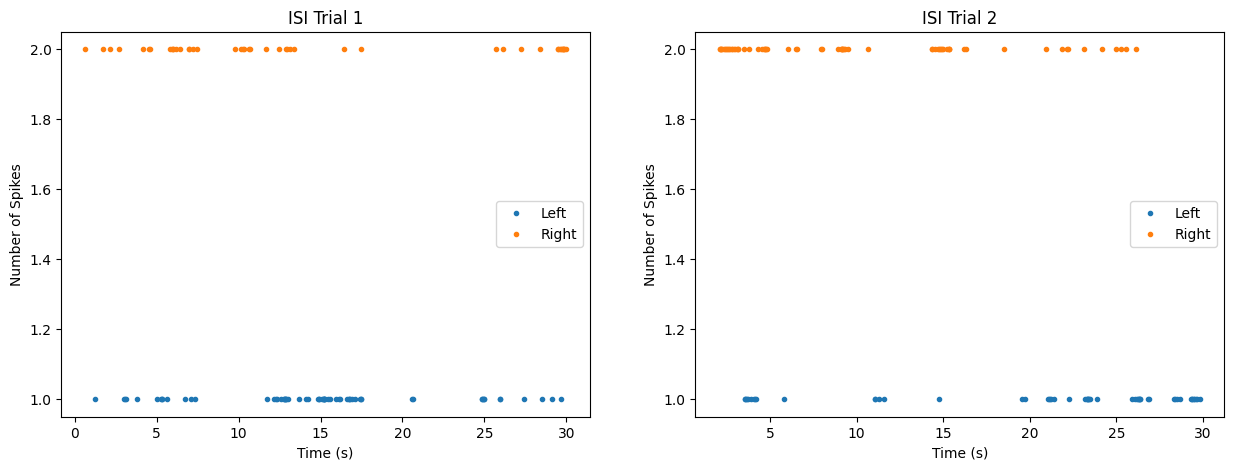

In [68]:
#making subplots and spike train data
fig, ax = plt.subplots(1,2,figsize=(15,5))
ax[0].plot(spikes_left_trial1,  np.ones_like(spikes_left_trial1),'.', label = 'Left')
ax[0].plot(spikes_right_trial1, 2 * np.ones_like(spikes_right_trial1), '.', label = 'Right')
ax[0].legend()
ax[0].set_title("ISI Trial 1")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Number of Spikes")

ax[1].plot(spikes_left_trial2,  np.ones_like(spikes_left_trial2), '.', label = 'Left')
ax[1].plot(spikes_right_trial2, 2 * np.ones_like(spikes_right_trial2), '.', label = 'Right')
ax[1].legend()
ax[1].set_title("ISI Trial 2")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Number of Spikes")

The neuron does appear to be bursty, both in the right and left direction conditions, and across trials.

In [36]:
#calculating interspike interval (ISI)
spikes_left_trial1_ISI = np.diff(spikes_left_trial1)
spikes_left_trial2_ISI = np.diff(spikes_left_trial2)
spikes_right_trial1_ISI = np.diff(spikes_right_trial1)
spikes_right_trial2_ISI = np.diff(spikes_right_trial2)

Text(0, 0.5, 'Count')

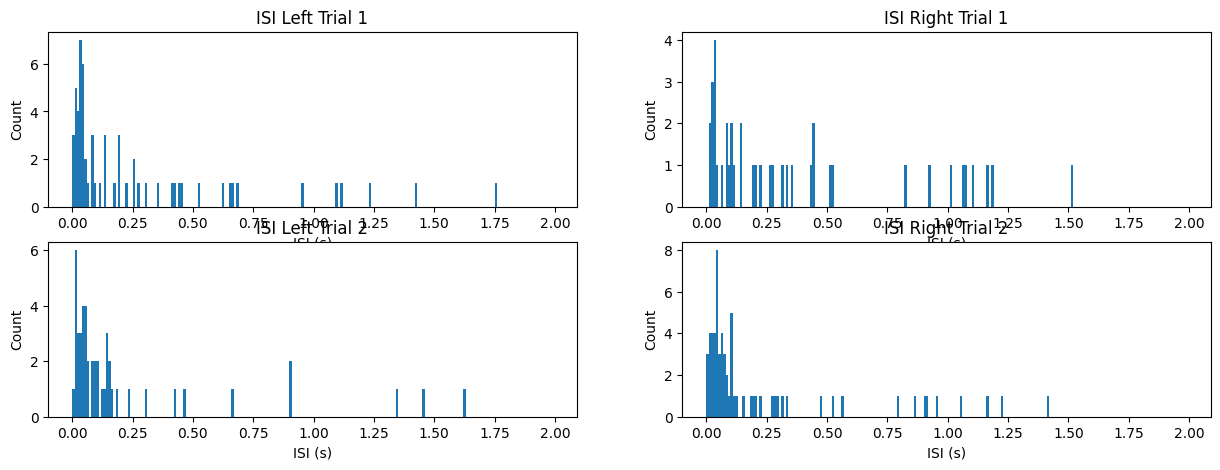

In [38]:
#Making 4 histograms

bins = np.arange(0, 2, 0.01)

fig, ax = plt.subplots(2,2,figsize=(15,5))
ax[0,0].hist(spikes_left_trial1_ISI, bins)
ax[0,0].set_title("ISI Left Trial 1")
ax[0,0].set_xlabel("ISI (s)")
ax[0,0].set_ylabel("Count")

ax[0,1].hist(spikes_right_trial1_ISI, bins)
ax[0,1].set_title("ISI Right Trial 1")
ax[0,1].set_xlabel("ISI (s)")
ax[0,1].set_ylabel("Count")

ax[1,0].hist(spikes_left_trial2_ISI, bins)
ax[1,0].set_title("ISI Left Trial 2")
ax[1,0].set_xlabel("ISI (s)")
ax[1,0].set_ylabel("Count")

ax[1,1].hist(spikes_right_trial2_ISI, bins)
ax[1,1].set_title("ISI Right Trial 2")
ax[1,1].set_xlabel("ISI (s)")
ax[1,1].set_ylabel("Count")

This neuron tends to fire in bursts, the burstiness seems about the same to me regardless of direction.

Text(0, 0.5, 'Firing Rate [Hz]')

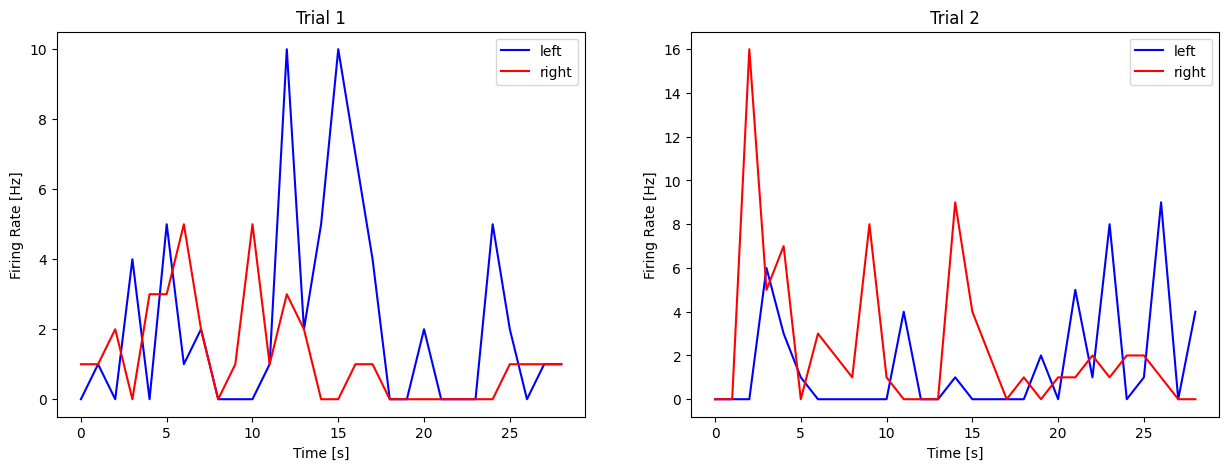

In [63]:
#firing rate over time
#firing rate over time for left trial 1
binsize = 1
fr_bins = np.arange(0,30,binsize)
fr_left1 = np.zeros(len(fr_bins)-1)
for i in range(len(fr_bins)-1):
  spk_index = (spikes_left_trial1 > fr_bins[i]) & (spikes_left_trial1 < fr_bins[i+1])
  true_values = spikes_left_trial1[spk_index]
  fr_left1[i] = (len(true_values))/binsize                                      # Divide number of spikes (timestamps) by our bin size to get firing rate

#firing rate over time for right trial 1
binsize = 1
fr_bins = np.arange(0,30,binsize)
fr_right1 = np.zeros(len(fr_bins)-1)
for i in range(len(fr_bins)-1):
  spk_index = (spikes_right_trial1 > fr_bins[i]) & (spikes_right_trial1 < fr_bins[i+1])
  true_values = spikes_right_trial1[spk_index]
  fr_right1[i] = (len(true_values))/binsize

#firing rate over time for left trial 2
binsize = 1
fr_bins = np.arange(0,30,binsize)
fr_left2 = np.zeros(len(fr_bins)-1)
for i in range(len(fr_bins)-1):
  spk_index = (spikes_left_trial2 > fr_bins[i]) & (spikes_left_trial2 < fr_bins[i+1])
  true_values = spikes_left_trial2[spk_index]
  fr_left2[i] = (len(true_values))/binsize

#firing rate over time for right trial 2
binsize = 1
fr_bins = np.arange(0,30,binsize)
fr_right2 = np.zeros(len(fr_bins)-1)
for i in range(len(fr_bins)-1):
  spk_index = (spikes_right_trial2 > fr_bins[i]) & (spikes_right_trial2 < fr_bins[i+1])
  true_values = spikes_right_trial2[spk_index]
  fr_right2[i] = (len(true_values))/binsize

#plotting firing rates over time
fig, ax = plt.subplots(1,2,figsize=(15,5))
ax[0].plot(fr_bins[:-1], fr_left1, color = 'blue', label = 'left')
ax[0].plot(fr_bins[:-1], fr_right1, color = 'red', label = 'right')
ax[0].legend()
ax[0].set_title('Trial 1')
ax[0].set_xlabel('Time [s]')
ax[0].set_ylabel('Firing Rate [Hz]')

ax[1].plot(fr_bins[:-1], fr_left2, color = 'blue', label = 'left')
ax[1].plot(fr_bins[:-1], fr_right2, color = 'red', label = 'right')
ax[1].legend()
ax[1].set_title('Trial 2')
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('Firing Rate [Hz]')




The firing rate for the left direction appears to have a higher firing rate towards the middle/end in both trials. In the second trial, the right direction appears to have a higher firing rate at the start of the trial (0-20 seconds) compared to the left direction having a higher firing rate towards the end of the trial (about 20-30 seconds).